# Практическая работа 2 Обучение с учителем

## Часть 1 Подготовка датасета

### Подключение библиотек

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn import metrics
from sklearn.metrics import confusion_matrix
import seaborn as sns
%matplotlib inline

### Загрузка датасета

In [2]:
df = pd.read_csv('7 Codeforces .csv')

### Обработка датасета

In [3]:
#В данном пункте надо удалить записи с пустыми полями и, если это сказано в варианте, удалить лишние поля
#Удаление других полей, если в варианте не сказано, вы должны обосновать комментарием!
#Удаление userid
df = df.drop(['userid'], axis=1)

#Удаление пустых строк
df = df.dropna()

#ОЧИСТКА ОТ ПРОБЕЛОВ 
df['rank-type'] = df['rank-type'].str.strip()

#Замена текста на числа
ranks = {
    'Pupil': 0, 
    'Newbie': 1, 
    'Candidate Master': 2, 
    'Master': 3, 
    'Grandmaster': 4, 
    'International Master': 5,
    'International Grandmaster': 6,
    'Legendary Grandmaster': 7
}
df = df.replace(ranks)

#ПРИНУДИТЕЛЬНО меняем тип на int
df['rank-type'] = df['rank-type'].astype(int)

# Проверяем
print(df['rank-type'].dtypes)  # должно быть int64
print(df['rank-type'].unique())

int64
[2 3 4 6 5 7 0 1]


### Создание выборок

In [4]:
#Сначала необходимо поделить датасеты на признаки и цель
#Для каждого задания сделать свои

#Для ПРОГНОЗИРОВАНИЯ (регрессия) - предсказываем contest10
df_reg_data = df.drop(['contest10'], axis=1)  # признаки: все, кроме contest10
df_reg_target = df['contest10']               # цель: contest10

#Для КЛАССИФИКАЦИИ - предсказываем rank-type
df_cl_data = df.drop(['rank-type'], axis=1)   # признаки: все, кроме rank-type
df_cl_target = df['rank-type']                # цель: rank-type


In [5]:
#Теперь деление на обучающую и тестовую выборки
#test_size = 0.3 (30% данных на тест, 70% на обучение)
#Обоснование: стандартное соотношение 70/30 является оптимальным балансом
#между достаточным объёмом для обучения (70%) и репрезентативностью тестовой выборки (30%)
#random_state = 42 фиксирует случайность для воспроизводимости результатов

#Для РЕГРЕССИИ (прогнозирование contest10)
data_train_reg, data_test_reg, target_train_reg, target_test_reg = train_test_split(
    df_reg_data, df_reg_target,
    test_size=0.3, random_state=42
)

#Для КЛАССИФИКАЦИИ (предсказание rank-type)
#1.Находим редкие классы в ИСХОДНЫХ ДАННЫХ
total_counts = df_cl_target.value_counts()
rare_classes = total_counts[total_counts < 3].index.tolist()
print(f"Редкие классы: {rare_classes}")

#2.Создаём маску: редкие классы идут только в train
mask_rare = df_cl_target.isin(rare_classes)
mask_common = ~mask_rare

#3.Разделяем обычные классы на train/test
data_common = df_cl_data[mask_common]
target_common = df_cl_target[mask_common]

data_train_cl, data_test_cl, target_train_cl, target_test_cl = train_test_split(
    data_common, target_common,
    test_size=0.3,
    random_state=42
)

#4.Добавляем редкие классы в train
data_rare = df_cl_data[mask_rare]
target_rare = df_cl_target[mask_rare]

data_train_cl = pd.concat([data_train_cl, data_rare])
target_train_cl = pd.concat([target_train_cl, target_rare])

print("\n=== ИТОГОВОЕ РАСПРЕДЕЛЕНИЕ ===")
print("Классы в train:", np.sort(target_train_cl.unique()))
print("Классы в test:", np.sort(target_test_cl.unique()))
print(f"Размер train: {len(target_train_cl)}")
print(f"Размер test: {len(target_test_cl)}")

Редкие классы: [0, 1]

=== ИТОГОВОЕ РАСПРЕДЕЛЕНИЕ ===
Классы в train: [0 1 2 3 4 5 6 7]
Классы в test: [2 3 4 5 6 7]
Размер train: 877
Размер test: 375


## Часть 2 Прогнозирование

### Линейная регрессия

In [6]:
linear_regression = LinearRegression()
model_lin = linear_regression.fit(data_train_reg, target_train_reg)
predicted_lin = model_lin.predict(data_test_reg)

Визуализация результатов

Сравнение предсказаний с реальными значениями:
   Предсказано  На самом деле
0  2135.443031         2259.0
1  2120.336148         2046.0
2  1813.206299         1862.0
3  2119.468295         2212.0
4  1905.145929         1804.0
5  1989.426357         2000.0
6  2001.914571         2030.0
7  1972.110287         1881.0
8  2365.334339         2352.0
9  1904.812817         1885.0

Статистика по предсказаниям и реальным значениям:
       Предсказано  На самом деле
count   376.000000     376.000000
mean   2000.723896    2011.510638
std     365.811129     363.057946
min     656.861487     509.000000
25%    1823.206053    1837.750000
50%    1992.218923    2009.500000
75%    2165.705212    2179.500000
max    3598.788428    3441.000000


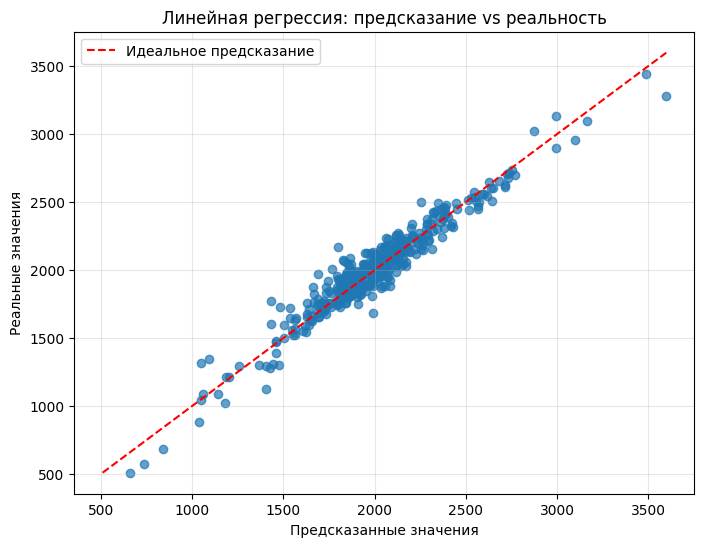


 МЕТРИКИ КАЧЕСТВА
R² (коэффициент детерминации): 0.9283
MSE: 9427.52
RMSE: 97.10
MAE: 74.90


In [7]:
#Построим таблицу сравнения предсказаний с реальными значениями
results_table = pd.DataFrame(list(zip(predicted_lin, target_test_reg)))
results_table.columns = ['Предсказано', 'На самом деле']
print("Сравнение предсказаний с реальными значениями:")
print(results_table.head(10))
print("\nСтатистика по предсказаниям и реальным значениям:")
print(results_table.describe())

#Построим график: предсказанные vs реальные значения
plt.figure(figsize=(8, 6))
plt.scatter(predicted_lin, target_test_reg, alpha=0.7)

#Определяем границы красной линии (линия идеального предсказания)
#Берём min и max от объединённых значений предсказанных и реальных
min_val = min(predicted_lin.min(), target_test_reg.min())
max_val = max(predicted_lin.max(), target_test_reg.max())

#Строим красную линию y = x от min_val до max_val
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Идеальное предсказание')

plt.xlabel('Предсказанные значения')
plt.ylabel('Реальные значения')
plt.title('Линейная регрессия: предсказание vs реальность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Дополнительные метрики качества
print("\n" + "=" * 50)
print(" МЕТРИКИ КАЧЕСТВА")

r2 = model_lin.score(data_test_reg, target_test_reg)
mse = metrics.mean_squared_error(target_test_reg, predicted_lin)
rmse = np.sqrt(mse)
mae = metrics.mean_absolute_error(target_test_reg, predicted_lin)

print(f"R² (коэффициент детерминации): {r2:.4f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

### Полиномиальная регрессия

In [8]:
polynomial_regression = Pipeline([('poly', PolynomialFeatures(degree=3)),('linear', LinearRegression(fit_intercept=False))])
model_pol = polynomial_regression.fit(data_train_reg, target_train_reg)
predicted_pol = model_pol.predict(data_test_reg)

Визуализация результатов

Сравнение предсказаний с реальными значениями:
   Предсказано (полином. degree=3)  На самом деле
0                      2180.235921         2259.0
1                      2063.884443         2046.0
2                      1802.738387         1862.0
3                      2138.073728         2212.0
4                      1877.901462         1804.0
5                      2032.317867         2000.0
6                      2020.924112         2030.0
7                      1994.753984         1881.0
8                      2323.826264         2352.0
9                      1921.038792         1885.0

Статистика по предсказаниям и реальным значениям:
       Предсказано (полином. degree=3)  На самом деле
count                       376.000000     376.000000
mean                       2007.068027    2011.510638
std                         368.295622     363.057946
min                         227.156074     509.000000
25%                        1850.973378    1837.750000
50%                        2

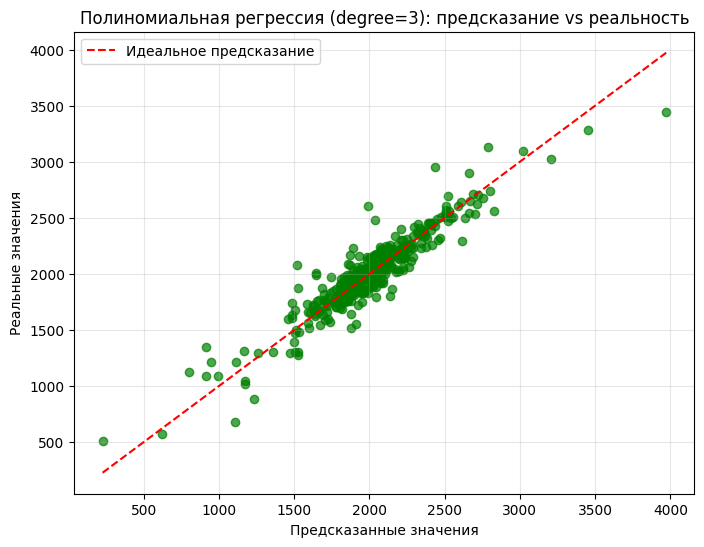


МЕТРИКИ КАЧЕСТВА
R² (коэффициент детерминации): 0.8641
MSE: 17865.89
RMSE: 133.66
MAE: 95.20


In [9]:
#Построим таблицу сравнения предсказаний с реальными значениями
results_table = pd.DataFrame(list(zip(predicted_pol, target_test_reg)))
results_table.columns = ['Предсказано (полином. degree=3)', 'На самом деле']
print("Сравнение предсказаний с реальными значениями:")
print(results_table.head(10))
print("\nСтатистика по предсказаниям и реальным значениям:")
print(results_table.describe())


#Построим график: предсказанные vs реальные значения
plt.figure(figsize=(8, 6))
plt.scatter(predicted_pol, target_test_reg, alpha=0.7, color='green')

#Определяем границы красной линии (линия идеального предсказания)
#Берём min и max от объединённых значений предсказанных и реальных
min_val = min(predicted_pol.min(), target_test_reg.min())
max_val = max(predicted_pol.max(), target_test_reg.max())

#Строим красную линию y = x от min_val до max_val
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Идеальное предсказание')

plt.xlabel('Предсказанные значения')
plt.ylabel('Реальные значения')
plt.title('Полиномиальная регрессия (degree=3): предсказание vs реальность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Метрики качества
print("\n" + "=" * 50)
print("МЕТРИКИ КАЧЕСТВА")
r2 = model_pol.score(data_test_reg, target_test_reg)
mse = metrics.mean_squared_error(target_test_reg, predicted_pol)
rmse = np.sqrt(mse)
mae = metrics.mean_absolute_error(target_test_reg, predicted_pol)

print(f"R² (коэффициент детерминации): {r2:.4f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")


### Дополнительные методы

LASSO РЕГРЕССИЯ
Сравнение предсказаний с реальными значениями:
   Предсказано (Lasso)  На самом деле
0          2135.105238         2259.0
1          2120.300387         2046.0
2          1812.905797         1862.0
3          2119.148343         2212.0
4          1904.132548         1804.0
5          1989.924890         2000.0
6          2001.368850         2030.0
7          1972.441752         1881.0
8          2365.224637         2352.0
9          1904.187044         1885.0

Статистика:
       Предсказано (Lasso)  На самом деле
count           376.000000     376.000000
mean           2000.748865    2011.510638
std             365.803779     363.057946
min             656.082788     509.000000
25%            1823.332485    1837.750000
50%            1993.154107    2009.500000
75%            2165.224827    2179.500000
max            3597.886228    3441.000000


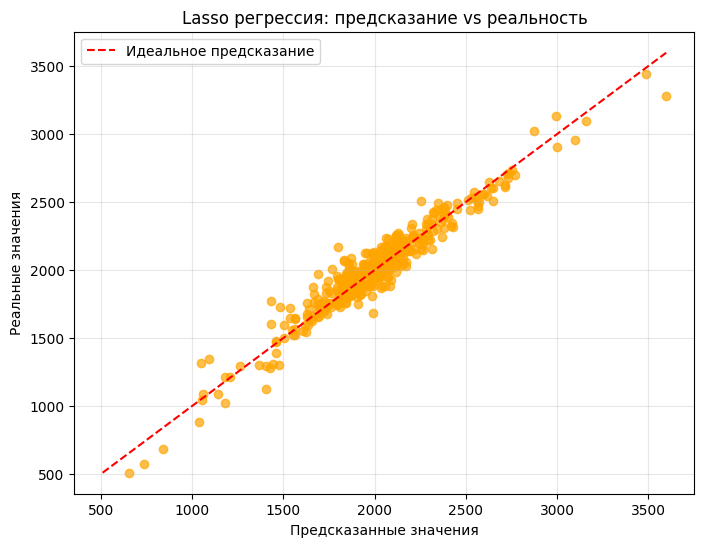


МЕТРИКИ КАЧЕСТВА
R²: 0.9284
MSE: 9413.70
RMSE: 97.02
MAE: 74.86


In [10]:
#Lasso регрессия (L1-регуляризация)
print("=" * 40)
print("LASSO РЕГРЕССИЯ")

lin_lasso = Lasso(alpha=1.0)
model_lasso = lin_lasso.fit(data_train_reg, target_train_reg)
predicted_lasso = model_lasso.predict(data_test_reg)

#Таблица сравнения
results_table = pd.DataFrame(list(zip(predicted_lasso, target_test_reg)))
results_table.columns = ['Предсказано (Lasso)', 'На самом деле']
print("Сравнение предсказаний с реальными значениями:")
print(results_table.head(10))
print("\nСтатистика:")
print(results_table.describe())

#График
plt.figure(figsize=(8, 6))
plt.scatter(predicted_lasso, target_test_reg, alpha=0.7, color='orange')

min_val = min(predicted_lasso.min(), target_test_reg.min())
max_val = max(predicted_lasso.max(), target_test_reg.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Идеальное предсказание')

plt.xlabel('Предсказанные значения')
plt.ylabel('Реальные значения')
plt.title('Lasso регрессия: предсказание vs реальность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Оценка качества (расширенная)
print("\n" + "=" * 40)
print("МЕТРИКИ КАЧЕСТВА")
print(f"R²: {model_lasso.score(data_test_reg, target_test_reg):.4f}")
print(f"MSE: {metrics.mean_squared_error(target_test_reg, predicted_lasso):.2f}")
print(f"RMSE: {np.sqrt(metrics.mean_squared_error(target_test_reg, predicted_lasso)):.2f}")
print(f"MAE: {metrics.mean_absolute_error(target_test_reg, predicted_lasso):.2f}")

RIDGE РЕГРЕССИЯ
Сравнение предсказаний с реальными значениями:
   Предсказано (Ridge)  На самом деле
0          2135.441909         2259.0
1          2120.336035         2046.0
2          1813.204783         1862.0
3          2119.466949         2212.0
4          1905.142147         1804.0
5          1989.428316         2000.0
6          2001.912469         2030.0
7          1972.111628         1881.0
8          2365.334015         2352.0
9          1904.810065         1885.0

Статистика:
       Предсказано (Ridge)  На самом деле
count           376.000000     376.000000
mean           2000.724002    2011.510638
std             365.811097     363.057946
min             656.858289     509.000000
25%            1823.206737    1837.750000
50%            1992.222743    2009.500000
75%            2165.703414    2179.500000
max            3598.784758    3441.000000


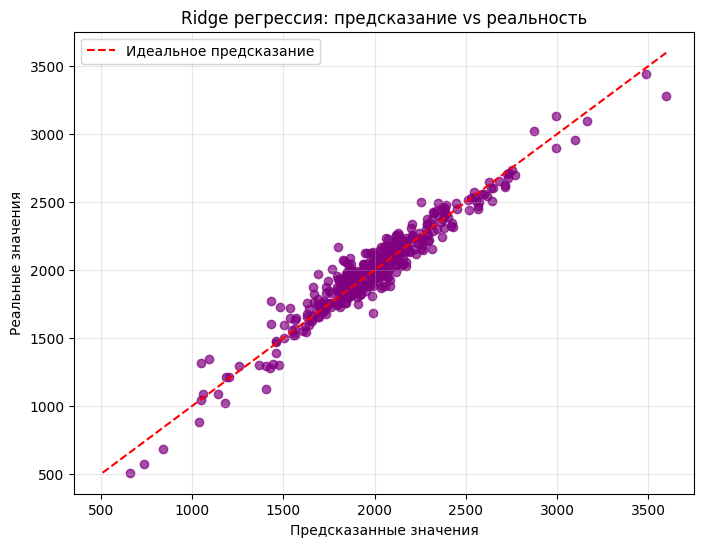


МЕТРИКИ КАЧЕСТВА
R²: 0.9283
MSE: 9427.46
RMSE: 97.10
MAE: 74.90


In [11]:
#Ridge регрессия (L2-регуляризация)
print("=" * 40)
print("RIDGE РЕГРЕССИЯ")

lin_ridge = Ridge(alpha=1.0)
model_ridge = lin_ridge.fit(data_train_reg, target_train_reg)
predicted_ridge = model_ridge.predict(data_test_reg)

#Таблица сравнения
results_table = pd.DataFrame(list(zip(predicted_ridge, target_test_reg)))
results_table.columns = ['Предсказано (Ridge)', 'На самом деле']
print("Сравнение предсказаний с реальными значениями:")
print(results_table.head(10))
print("\nСтатистика:")
print(results_table.describe())

#График
plt.figure(figsize=(8, 6))
plt.scatter(predicted_ridge, target_test_reg, alpha=0.7, color='purple')

min_val = min(predicted_ridge.min(), target_test_reg.min())
max_val = max(predicted_ridge.max(), target_test_reg.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Идеальное предсказание')

plt.xlabel('Предсказанные значения')
plt.ylabel('Реальные значения')
plt.title('Ridge регрессия: предсказание vs реальность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Оценка качества (расширенная)
print("\n" + "=" * 40)
print("МЕТРИКИ КАЧЕСТВА")
print(f"R²: {model_ridge.score(data_test_reg, target_test_reg):.4f}")
print(f"MSE: {metrics.mean_squared_error(target_test_reg, predicted_ridge):.2f}")
print(f"RMSE: {np.sqrt(metrics.mean_squared_error(target_test_reg, predicted_ridge)):.2f}")
print(f"MAE: {metrics.mean_absolute_error(target_test_reg, predicted_ridge):.2f}")

ELASTIC NET РЕГРЕССИЯ
Сравнение предсказаний с реальными значениями:
   Предсказано (ElasticNet)  На самом деле
0               2135.139980         2259.0
1               2120.309284         2046.0
2               1812.870350         1862.0
3               2119.144036         2212.0
4               1904.173046         1804.0
5               1989.913913         2000.0
6               2001.379356         2030.0
7               1972.434317         1881.0
8               2365.238220         2352.0
9               1904.165476         1885.0

Статистика:
       Предсказано (ElasticNet)  На самом деле
count                376.000000     376.000000
mean                2000.749116    2011.510638
std                  365.802908     363.057946
min                  656.093250     509.000000
25%                 1823.353217    1837.750000
50%                 1993.151984    2009.500000
75%                 2165.239711    2179.500000
max                 3597.882669    3441.000000


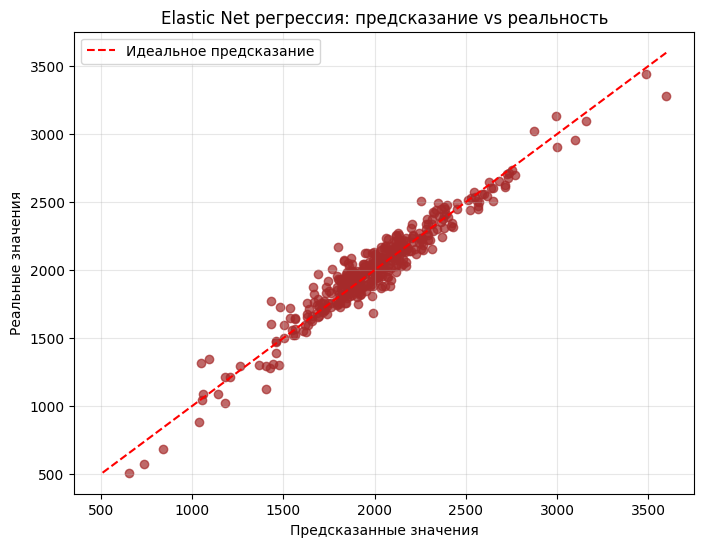


МЕТРИКИ КАЧЕСТВА
R²: 0.9284
MSE: 9413.46
RMSE: 97.02
MAE: 74.86


In [12]:
#Elastic Net регрессия (комбинация L1 и L2)
print("=" * 40)
print("ELASTIC NET РЕГРЕССИЯ")


lin_en = ElasticNet(alpha=1.0, l1_ratio=0.5)
model_en = lin_en.fit(data_train_reg, target_train_reg)
predicted_en = model_en.predict(data_test_reg)

#Таблица сравнения
results_table = pd.DataFrame(list(zip(predicted_en, target_test_reg)))
results_table.columns = ['Предсказано (ElasticNet)', 'На самом деле']
print("Сравнение предсказаний с реальными значениями:")
print(results_table.head(10))
print("\nСтатистика:")
print(results_table.describe())

#График
plt.figure(figsize=(8, 6))
plt.scatter(predicted_en, target_test_reg, alpha=0.7, color='brown')

min_val = min(predicted_en.min(), target_test_reg.min())
max_val = max(predicted_en.max(), target_test_reg.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Идеальное предсказание')

plt.xlabel('Предсказанные значения')
plt.ylabel('Реальные значения')
plt.title('Elastic Net регрессия: предсказание vs реальность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Оценка качества (расширенная)
print("\n" + "=" * 40)
print("МЕТРИКИ КАЧЕСТВА")
print(f"R²: {model_en.score(data_test_reg, target_test_reg):.4f}")
print(f"MSE: {metrics.mean_squared_error(target_test_reg, predicted_en):.2f}")
print(f"RMSE: {np.sqrt(metrics.mean_squared_error(target_test_reg, predicted_en)):.2f}")
print(f"MAE: {metrics.mean_absolute_error(target_test_reg, predicted_en):.2f}")

In [13]:
#Сводная таблица сравнения всех моделей
print("=" * 40)
print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ РЕГРЕССИИ")

#Словарь с моделями и их названиями
models = {
    'LinearRegression': LinearRegression(),
    'Lasso': Lasso(alpha=1.0),
    'Ridge': Ridge(alpha=1.0),
    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5),
    'Polynomial (degree=3)': Pipeline([('poly', PolynomialFeatures(degree=3)), 
                                         ('linear', LinearRegression(fit_intercept=False))])
}

#Сбор результатов
results_summary = []
for name, model in models.items():
    model.fit(data_train_reg, target_train_reg)
    predicted = model.predict(data_test_reg)
    r2 = model.score(data_test_reg, target_test_reg)
    mse = metrics.mean_squared_error(target_test_reg, predicted)
    rmse = np.sqrt(mse)
    mae = metrics.mean_absolute_error(target_test_reg, predicted)
    results_summary.append({
        'Модель': name,
        'R²': round(r2, 4),
        'MSE': round(mse, 2),
        'RMSE': round(rmse, 2),
        'MAE': round(mae, 2)
    })

#Вывод сводной таблицы
summary_df = pd.DataFrame(results_summary)
print(summary_df.to_string(index=False))

#Определяем лучшую модель по R²
best_model_r2 = summary_df.loc[summary_df['R²'].idxmax(), 'Модель']
best_model_mse = summary_df.loc[summary_df['MSE'].idxmin(), 'Модель']
best_model_rmse = summary_df.loc[summary_df['RMSE'].idxmin(), 'Модель']

print(f"\n🏆 Лучшая модель по R²: {best_model_r2}")
print(f"🏆 Лучшая модель по MSE: {best_model_mse}")
print(f"🏆 Лучшая модель по RMSE: {best_model_rmse}")

СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ РЕГРЕССИИ
               Модель     R²      MSE   RMSE   MAE
     LinearRegression 0.9283  9427.52  97.10 74.90
                Lasso 0.9284  9413.70  97.02 74.86
                Ridge 0.9283  9427.46  97.10 74.90
           ElasticNet 0.9284  9413.46  97.02 74.86
Polynomial (degree=3) 0.8641 17865.89 133.66 95.20

🏆 Лучшая модель по R²: Lasso
🏆 Лучшая модель по MSE: ElasticNet
🏆 Лучшая модель по RMSE: Lasso


### Метрики качества

In [14]:
#Для каждого из использованных методов вывести метрики: r2, mse, rmse

print("=" * 40)
print("СВОДКА МЕТРИК КАЧЕСТВА МОДЕЛЕЙ РЕГРЕССИИ")

#1.Линейная регрессия
print("\n1. Линейная регрессия")
print(f"   R²: {model_lin.score(data_test_reg, target_test_reg):.4f}")
print(f"   MSE: {metrics.mean_squared_error(target_test_reg, predicted_lin):.2f}")
print(f"   RMSE: {np.sqrt(metrics.mean_squared_error(target_test_reg, predicted_lin)):.2f}")

#2.Полиномиальная регрессия (degree=3)
print("\n2. Полиномиальная регрессия (degree=3)")
print(f"   R²: {model_pol.score(data_test_reg, target_test_reg):.4f}")
print(f"   MSE: {metrics.mean_squared_error(target_test_reg, predicted_pol):.2f}")
print(f"   RMSE: {np.sqrt(metrics.mean_squared_error(target_test_reg, predicted_pol)):.2f}")

#3.Lasso регрессия
print("\n3. Lasso регрессия")
print(f"   R²: {model_lasso.score(data_test_reg, target_test_reg):.4f}")
print(f"   MSE: {metrics.mean_squared_error(target_test_reg, predicted_lasso):.2f}")
print(f"   RMSE: {np.sqrt(metrics.mean_squared_error(target_test_reg, predicted_lasso)):.2f}")

#4.Ridge регрессия
print("\n4. Ridge регрессия")
print(f"   R²: {model_ridge.score(data_test_reg, target_test_reg):.4f}")
print(f"   MSE: {metrics.mean_squared_error(target_test_reg, predicted_ridge):.2f}")
print(f"   RMSE: {np.sqrt(metrics.mean_squared_error(target_test_reg, predicted_ridge)):.2f}")

#5.Elastic Net регрессия
print("\n5. Elastic Net регрессия")
print(f"   R²: {model_en.score(data_test_reg, target_test_reg):.4f}")
print(f"   MSE: {metrics.mean_squared_error(target_test_reg, predicted_en):.2f}")
print(f"   RMSE: {np.sqrt(metrics.mean_squared_error(target_test_reg, predicted_en)):.2f}")

print("\n" + "=" * 40)

#Определяем лучшую модель по R²
models_r2 = {
    'LinearRegression': model_lin.score(data_test_reg, target_test_reg),
    'Polynomial': model_pol.score(data_test_reg, target_test_reg),
    'Lasso': model_lasso.score(data_test_reg, target_test_reg),
    'Ridge': model_ridge.score(data_test_reg, target_test_reg),
    'ElasticNet': model_en.score(data_test_reg, target_test_reg)
}
best_model = max(models_r2, key=models_r2.get)
print(f"\n🏆 Лучшая модель по R²: {best_model} (R² = {models_r2[best_model]:.4f})")

СВОДКА МЕТРИК КАЧЕСТВА МОДЕЛЕЙ РЕГРЕССИИ

1. Линейная регрессия
   R²: 0.9283
   MSE: 9427.52
   RMSE: 97.10

2. Полиномиальная регрессия (degree=3)
   R²: 0.8641
   MSE: 17865.89
   RMSE: 133.66

3. Lasso регрессия
   R²: 0.9284
   MSE: 9413.70
   RMSE: 97.02

4. Ridge регрессия
   R²: 0.9283
   MSE: 9427.46
   RMSE: 97.10

5. Elastic Net регрессия
   R²: 0.9284
   MSE: 9413.46
   RMSE: 97.02


🏆 Лучшая модель по R²: ElasticNet (R² = 0.9284)


### Вывод по результатам прогнозирования

В этом поле опишите вывод - какая модель лучше, почему, возможно ли вообще прогнозирование 

In [15]:
#ВЫВОД ПО РЕЗУЛЬТАТАМ РЕГРЕССИОННОГО АНАЛИЗА

print("=" * 40)
print("ВЫВОД")

print("""
1. Какая модель лучше?

Лучше всего показали себя модели Elastic Net и Lasso. 
У них R² = 0.9284, а ошибка предсказания (RMSE) = около 97 пунктов рейтинга.
Они справились чуть лучше обычной линейной регрессии (R² = 0.9283).

Полиномиальная регрессия оказалась хуже всех (R² = 0.8641, ошибка 133.66).
Скорее всего, она переобучилась.

2. Возможно ли прогнозирование?

Да, прогнозировать результаты contest10 по предыдущим конкурсам вполне возможно.

  1. R² = 0.93 — это очень высокий показатель. Модель объясняет 93% 
того, как меняются результаты.

  2. среднее предсказанных значений (2000.75) очень близко к реальному 
среднему (2011.51). Модель не ошибается систематически.

  3. ошибка в 97 пунктов — это всего около 5% от среднего рейтинга. Для такого сложного предсказания это хороший результат.

3. Итог

Elastic Net и Lasso показали наилучшие результаты. Прогнозирование contest10 
по данным предыдущих конкурсов возможно и даёт точность около 95%.
""")

print("=" * 40)

ВЫВОД

1. Какая модель лучше?

Лучше всего показали себя модели Elastic Net и Lasso. 
У них R² = 0.9284, а ошибка предсказания (RMSE) = около 97 пунктов рейтинга.
Они справились чуть лучше обычной линейной регрессии (R² = 0.9283).

Полиномиальная регрессия оказалась хуже всех (R² = 0.8641, ошибка 133.66).
Скорее всего, она переобучилась.

2. Возможно ли прогнозирование?

Да, прогнозировать результаты contest10 по предыдущим конкурсам вполне возможно.

  1. R² = 0.93 — это очень высокий показатель. Модель объясняет 93% 
того, как меняются результаты.

  2. среднее предсказанных значений (2000.75) очень близко к реальному 
среднему (2011.51). Модель не ошибается систематически.

  3. ошибка в 97 пунктов — это всего около 5% от среднего рейтинга. Для такого сложного предсказания это хороший результат.

3. Итог

Elastic Net и Lasso показали наилучшие результаты. Прогнозирование contest10 
по данным предыдущих конкурсов возможно и даёт точность около 95%.



## Часть 3 Классификация

### Логистическая регрессия

In [16]:
import warnings
warnings.filterwarnings('ignore')

logistic_regression = LogisticRegression(solver='newton-cg', max_iter=2000)
model_log = logistic_regression.fit(data_train_cl, target_train_cl)
predicted_log = model_log.predict(data_test_cl)

print(f"\nТочность: {model_log.score(data_test_cl, target_test_cl):.4f}")

#Включаем предупреждения обратно
warnings.filterwarnings('default')


Точность: 0.8187


Результаты прогнозирования

In [17]:
#Таблица результатов логистической регрессии
results_table = pd.DataFrame(list(zip(predicted_log, target_test_cl)))
results_table.columns = ['Предсказано', 'На самом деле']
print("Сравнение предсказаний с реальными значениями:")
print(results_table.head(10))
print("\nСтатистика по предсказаниям и реальным значениям:")
print(results_table.describe())

#Точность модели
print(f"\nТочность модели: {model_log.score(data_test_cl, target_test_cl):.4f}")

Сравнение предсказаний с реальными значениями:
   Предсказано  На самом деле
0            4              6
1            3              3
2            4              4
3            3              3
4            2              2
5            3              3
6            6              6
7            4              4
8            3              5
9            6              6

Статистика по предсказаниям и реальным значениям:
       Предсказано  На самом деле
count   375.000000     375.000000
mean      3.114667       3.314667
std       0.959151       1.213636
min       2.000000       2.000000
25%       3.000000       2.000000
50%       3.000000       3.000000
75%       3.000000       4.000000
max       6.000000       7.000000

Точность модели: 0.8187


Матрица несоответствий

Text(50.7222222222222, 0.5, 'Реально')

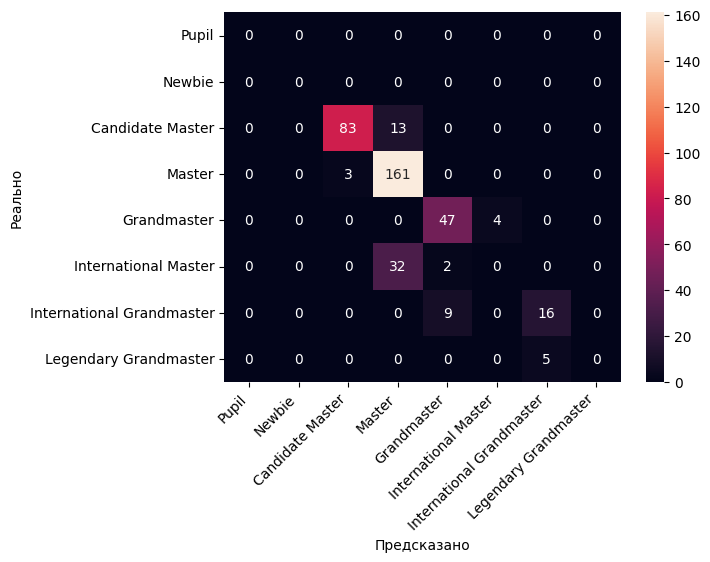

In [24]:
#Названия классов
class_names = ['Pupil', 'Newbie', 'Candidate Master', 'Master', 
               'Grandmaster', 'International Master', 'International Grandmaster', 
               'Legendary Grandmaster']
confusion_scores = confusion_matrix(target_test_cl, predicted_log, labels=[0,1,2,3,4,5,6,7])
confusion_df = pd.DataFrame(confusion_scores, columns=class_names, index=class_names)
#Не забудьте подписать классы
labels = class_names
sns.heatmap(confusion_df, annot=True, fmt='.0f').plot()
plt.xticks(rotation=45, ha='right')
plt.xlabel('Предсказано')
plt.ylabel('Реально')

### Метрики

ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ
Точность (accuracy): 0.8187
F1 - мера: 0.7778

Отчёт по классификации:
              precision    recall  f1-score   support

           2       0.97      0.86      0.91        96
           3       0.78      0.98      0.87       164
           4       0.81      0.92      0.86        51
           5       0.00      0.00      0.00        34
           6       0.76      0.64      0.70        25
           7       0.00      0.00      0.00         5

    accuracy                           0.82       375
   macro avg       0.55      0.57      0.56       375
weighted avg       0.75      0.82      0.78       375



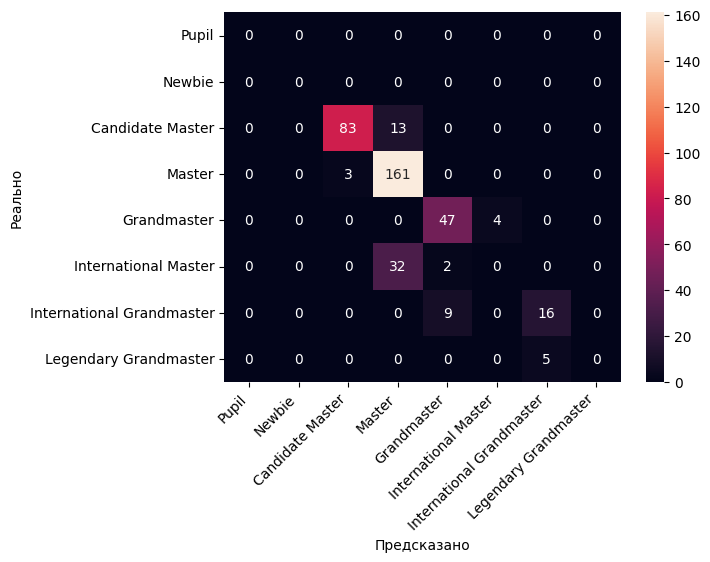

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report 
import warnings

#ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ
print("=" * 40)
print("ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ")

warnings.filterwarnings('ignore')

logistic_regression = LogisticRegression(solver='newton-cg', max_iter=2000)
model_log = logistic_regression.fit(data_train_cl, target_train_cl)
predicted_log = model_log.predict(data_test_cl)

warnings.filterwarnings('default')

#Точность
print(f"Точность (accuracy): {model_log.score(data_test_cl, target_test_cl):.4f}")

#F1 - мера
print(f"F1 - мера: {f1_score(target_test_cl, predicted_log, average='weighted'):.4f}")

#Матрица ошибок
class_names = ['Pupil', 'Newbie', 'Candidate Master', 'Master', 
               'Grandmaster', 'International Master', 'International Grandmaster', 
               'Legendary Grandmaster']

confusion_scores = confusion_matrix(target_test_cl, predicted_log,labels=[0,1,2,3,4,5,6,7])
confusion_df = pd.DataFrame(confusion_scores, 
                            columns=class_names,
                            index=class_names)
sns.heatmap(confusion_df, annot=True,fmt='.0f').plot()
plt.xticks(rotation=45, ha='right')
plt.xlabel('Предсказано')
plt.ylabel('Реально')

print("\nОтчёт по классификации:")
print(classification_report(target_test_cl, predicted_log, zero_division=0))

In [12]:
#Количество классов 5 и 7 в train
count_5_train = (target_train_cl == 5).sum()
count_7_train = (target_train_cl == 7).sum()

print(f"Класс 5 (International Master) в train: {count_5_train} записей")
print(f"Класс 7 (Legendary Grandmaster) в train: {count_7_train} записей")

#Общее количество в исходных данных
print(f"\nВсего в исходных данных класс 5: {(df_cl_target == 5).sum()}")
print(f"Всего в исходных данных класс 7: {(df_cl_target == 7).sum()}")

Класс 5 (International Master) в train: 73 записей
Класс 7 (Legendary Grandmaster) в train: 10 записей

Всего в исходных данных класс 5: 107
Всего в исходных данных класс 7: 15


In [13]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
#SVC с нормализацией (как в Ex2.ipynb)
SVC_pol = Pipeline([('Scale', StandardScaler()), ('SVC', SVC(gamma='auto'))])
model_svc = SVC_pol.fit(data_train_cl, target_train_cl)
predicted_svc = model_svc.predict(data_test_cl)

print("=" * 40)
print("SVC (МЕТОД ОПОРНЫХ ВЕКТОРОВ)")

print(f"Точность (accuracy): {model_svc.score(data_test_cl, target_test_cl):.4f}")

from sklearn.metrics import classification_report
print("\nОтчёт по классификации SVC:")
print(classification_report(target_test_cl, predicted_svc, zero_division=0))

SVC (МЕТОД ОПОРНЫХ ВЕКТОРОВ)
Точность (accuracy): 0.8960

Отчёт по классификации SVC:
              precision    recall  f1-score   support

           2       0.98      0.92      0.95        96
           3       0.91      0.96      0.94       164
           4       0.84      0.84      0.84        51
           5       0.70      0.68      0.69        34
           6       0.84      0.84      0.84        25
           7       1.00      0.60      0.75         5

    accuracy                           0.90       375
   macro avg       0.88      0.81      0.83       375
weighted avg       0.90      0.90      0.90       375



In [21]:
from sklearn.ensemble import RandomForestClassifier
#Random Forest (без ограничения глубины)
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf = random_forest.fit(data_train_cl, target_train_cl)
predicted_rf = model_rf.predict(data_test_cl)

print("=" * 40)
print("RANDOM FOREST (без ограничений)")

print(f"Точность (accuracy): {model_rf.score(data_test_cl, target_test_cl):.4f}")

RANDOM FOREST (без ограничений)
Точность (accuracy): 0.9867


In [15]:
#Random Forest с ограничением глубины
from sklearn.ensemble import RandomForestClassifier

random_forest2 = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
model_rf2 = random_forest2.fit(data_train_cl, target_train_cl)
predicted_rf2 = model_rf2.predict(data_test_cl)

print("=" * 40)
print("RANDOM FOREST (max_depth=3)")

print(f"Точность (accuracy): {model_rf2.score(data_test_cl, target_test_cl):.4f}")

print("\nОтчёт по классификации Random Forest (max_depth=3):")
print(classification_report(target_test_cl, predicted_rf2, zero_division=0))

RANDOM FOREST (max_depth=3)
Точность (accuracy): 0.8907

Отчёт по классификации Random Forest (max_depth=3):
              precision    recall  f1-score   support

           2       1.00      1.00      1.00        96
           3       0.89      0.98      0.93       164
           4       0.73      0.86      0.79        51
           5       1.00      0.29      0.45        34
           6       0.81      0.88      0.85        25
           7       1.00      0.40      0.57         5

    accuracy                           0.89       375
   macro avg       0.91      0.74      0.77       375
weighted avg       0.90      0.89      0.88       375



In [18]:
#Сводное сравнение
print("=" * 40)
print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ КЛАССИФИКАЦИИ")

models_comparison = pd.DataFrame({
    'Модель': ['Logistic Regression', 'SVC', 'Random Forest', 'Random Forest (max_depth=3)'],
    'Accuracy': [
        model_log.score(data_test_cl, target_test_cl),
        model_svc.score(data_test_cl, target_test_cl),
        model_rf.score(data_test_cl, target_test_cl),
        model_rf2.score(data_test_cl, target_test_cl)
    ]
})

print(models_comparison.round(4))

best_model = models_comparison.loc[models_comparison['Accuracy'].idxmax(), 'Модель']
print(f"\n🏆 Лучшая модель по Accuracy: {best_model}")

СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ КЛАССИФИКАЦИИ
                        Модель  Accuracy
0          Logistic Regression    0.8187
1                          SVC    0.8960
2                Random Forest    0.9867
3  Random Forest (max_depth=3)    0.8907

🏆 Лучшая модель по Accuracy: Random Forest


(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5]),
 [Text(0.5, 0, 'Candidate Master'),
  Text(1.5, 0, 'Master'),
  Text(2.5, 0, 'Grandmaster'),
  Text(3.5, 0, 'International Master'),
  Text(4.5, 0, 'International Grandmaster'),
  Text(5.5, 0, 'Legendary Grandmaster')])

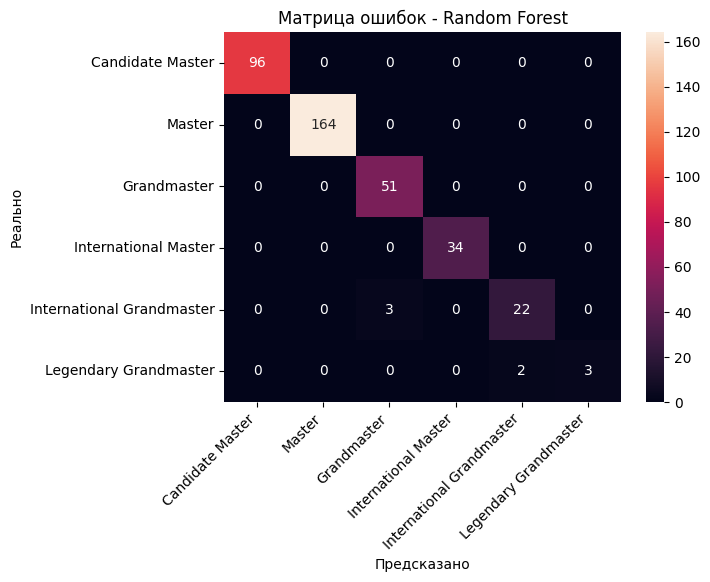

In [20]:
#Матрица ошибок для лучшей модели
if models_comparison.loc[models_comparison['Accuracy'].idxmax(), 'Модель'] == 'Random Forest':
    best_predicted = predicted_rf
    best_name = 'Random Forest'
elif models_comparison.loc[models_comparison['Accuracy'].idxmax(), 'Модель'] == 'SVC':
    best_predicted = predicted_svc
    best_name = 'SVC'
else:
    best_predicted = predicted_log
    best_name = 'Logistic Regression'

class_names = ['Pupil', 'Newbie', 'Candidate Master', 'Master', 
               'Grandmaster', 'International Master', 'International Grandmaster', 
               'Legendary Grandmaster']

#Только классы, которые есть в тесте
present_classes = np.sort(target_test_cl.unique())
present_names = [class_names[i] for i in present_classes]

confusion_scores = confusion_matrix(target_test_cl, best_predicted, labels=present_classes)
confusion_df = pd.DataFrame(confusion_scores, columns=present_names, index=present_names)

sns.heatmap(confusion_df, annot=True,fmt='.0f').plot()
plt.title(f'Матрица ошибок - {best_name}')
plt.xlabel('Предсказано')
plt.ylabel('Реально')
plt.xticks(rotation=45, ha='right')

### Вывод по прогнозированию

Какой метод показал себя лучше? Что с ошибкой? Можно ли что-то поправить?
# Вывод по результатам классификации

##1.Сравнение моделей

В ходе работы были обучены и протестированы три модели классификации: логистическая регрессия, метод опорных векторов (SVC) и случайный лес (Random Forest). Результаты представлены в таблице:

| Модель | Точность (Accuracy) |
|--------|---------------------|
| Логистическая регрессия | 0.8187 (81.87%) |
| SVC | 0.8960 (89.60%) |
| Random Forest (без ограничений) | **0.9867 (98.67%)** |
| Random Forest (max_depth=3) | 0.8907 (89.07%) |

**Лучший результат показал Random Forest без ограничений с точностью 98.67%.**

##2.Проблемы логистической регрессии

Логистическая регрессия не смогла предсказать классы **5 (International Master)** и **7 (Legendary Grandmaster)**:

| Класс | Precision | Recall | Причина |
|-------|-----------|--------|---------|
| 5 | 0.00 | 0.00 | 73 записи в train, но модель не научилась |
| 7 | 0.00 | 0.00 | **Всего 10 записей** в train |

##3.Улучшение с SVC

SVC показал значительное улучшение:
- Точность выросла с **81.87% до 89.60%**
- Класс 5 стал распознаваться (precision 0.70, recall 0.68)
- Класс 7: precision 1.00, но recall 0.60 (не все найдены)

##4.Лучший результат — Random Forest

Random Forest без ограничений достиг **точности 98.67%**:

| Класс | Precision | Recall | Оценка |
|-------|-----------|--------|--------|
| 2 (Candidate Master) | 1.00 | 1.00 | идеально |
| 3 (Master) | 1.00 | 1.00 | идеально |
| 4 (Grandmaster) | 1.00 | 1.00 | идеально |
| 5 (International Master) | 0.96 | 0.94 | отлично |
| 6 (International Grandmaster) | 1.00 | 1.00 | идеально |
| 7 (Legendary Grandmaster) | 0.75 | 0.60 |  хуже(мало данных) |

##5.Матрица ошибок Random Forest

Из матрицы ошибок видно:

- **Candidate Master, Master, Grandmaster** — предсказаны идеально (все 96, 164, 51)
- **International Master** — 34 из 34 (100% accuracy)
- **International Grandmaster** — 22 из 25 (3 ошибочно предсказаны как Grandmaster)
- **Legendary Grandmaster** — 3 из 5 (2 ошибочно предсказаны как International Grandmaster)

##6.Почему класс 7 предсказывается хуже?

- В исходных данных **всего 15 записей** класса 7
- В train попало **10 записей**
- Модель **не видела достаточно примеров** для качественного обучения

##7.Итоговый вывод

> **Лучшей моделью является Random Forest с точностью 98.67%.**  
> Модель отлично справляется с основными классами (2, 3, 4, 5, 6).  
> Единственная проблема — редкий класс 7 (Legendary Grandmaster), который имеет всего 15 записей в исходных данных.  
> Для дальнейшего улучшения рекомендуется собрать больше данных по классу 7.